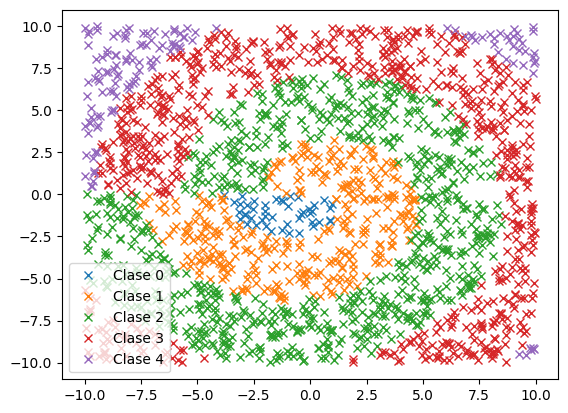

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

L=2000
x=np.random.rand(L)*20-10
y=np.random.rand(L)*20-10
r=np.sqrt(x**2+y**2)
angle=np.arctan2(y,x)*180/np.pi+r*60+180
Nc=5
paso=np.max(angle)/Nc
clase=np.array([int(ang/paso) if not(np.isnan(ang)) else 0 for ang in angle])
clase[clase>=Nc]=Nc-1
X=np.array([x,y]).T
Y=np.array(clase)
for i in range(np.max(clase)+1):
  l=plt.plot(x[clase==i], y[clase==i],'x', label='Clase '+str(i))
plt.legend()
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.3)

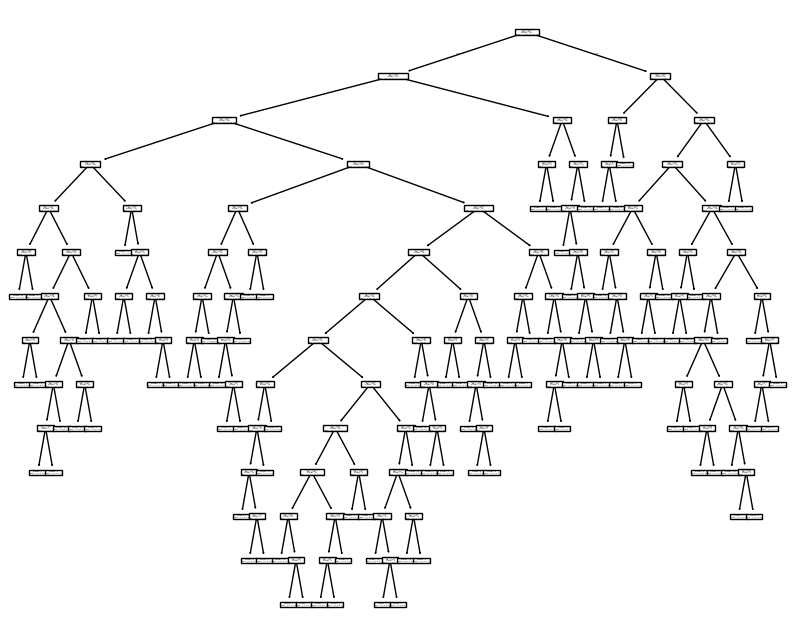

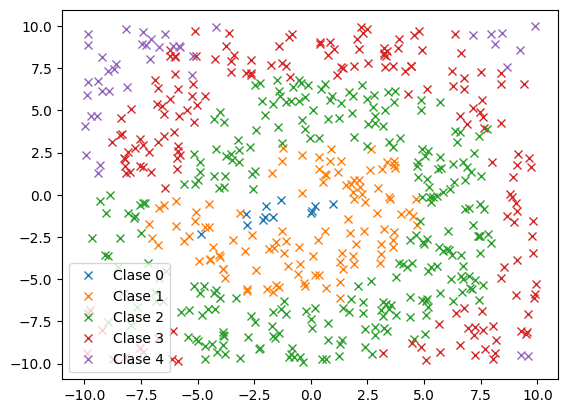

In [ ]:
#modelo de clasificación basado en regresión árbol
from sklearn.tree import DecisionTreeClassifier, plot_tree
#from sklearn.metrics import plot_roc_curve
modelT=DecisionTreeClassifier(max_depth=20)
modelT.fit(X_train,Y_train)
plt.figure(figsize=(10,8))
txt=plot_tree(modelT)
plt.figure()
pred=modelT.predict(X_test)
for i in range(np.max(pred)+1):
  l=plt.plot(X_test[pred==i,0], X_test[pred==i,1],'x', label='Clase '+str(i))
plt.legend()


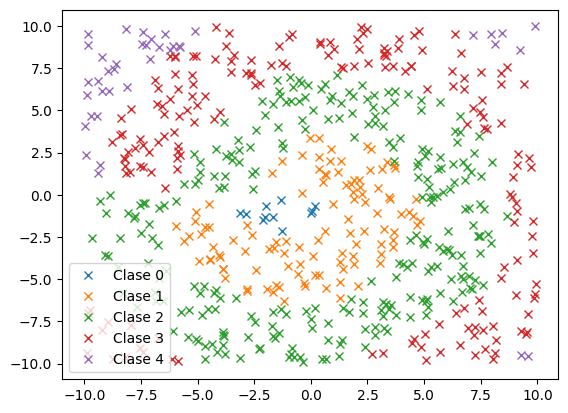

In [ ]:
#modelo de clasificación basado en regresión árbol
from sklearn.svm import SVR
modelSVM=SVR(kernel='rbf', gamma=0.7, C=1)
modelSVM.fit(X_train,Y_train)
pred=modelSVM.predict(X_test)
pred=np.array([int(np.round(x)) for x in pred])
for i in range(Nc):
  l=plt.plot(X_test[pred==i,0], X_test[pred==i,1],'x', label='Clase '+str(i))
plt.legend()
#print(X_test)

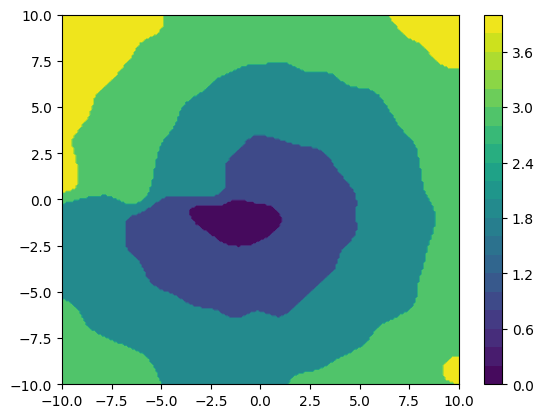

In [ ]:
L=10000
x,y=np.meshgrid(np.linspace(-10,10,200),np.linspace(-10,10,200))
n,m=x.shape
vx=x.reshape(n*m,1).ravel()
vy=y.reshape(n*m,1).ravel()
X=np.array([vx,vy]).T
pred=modelSVM.predict(X)
pred=np.array([int(np.round(x)) for x in pred])
x=vx.reshape(n,m)
y=vy.reshape(n,m)
z=pred.reshape(n,m)
#print(z)
plt.contourf(x,y,z,20)
plt.colorbar()

In [ ]:
#Desde el punto de vista de PyTorch, el modelo es similar, simplemente se agrega una función lineal de las variables de entrada
import torch
x = torch.tensor(X_train).float()
y = torch.tensor(Y_train).float()

model = torch.nn.Sequential(
    torch.nn.Linear(2, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 100),
    torch.nn.ReLU(),
    torch.nn.Linear(100, 1),
    torch.nn.Flatten(0, 1)
)

loss_fn = torch.nn.MSELoss(reduction='sum')
learning_rate = 1e-5
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

for t in range(10000):
    # Forward pass: compute predicted y by passing x to the model.
    y_pred = model(x.float())

    # Compute and print loss.
    loss = loss_fn(y_pred, y)
    if t % 1000 == 99:
        print(t, loss.item())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

x_test = torch.tensor(X_test).float()
y_test = torch.tensor(Y_test).float()



99 141.12533569335938
1099 112.53123474121094
2099 106.78509521484375
3099 112.38923645019531
4099 106.21170043945312
5099 110.57061004638672
6099 105.58472442626953
7099 104.62405395507812
8099 102.33769989013672
9099 100.39132690429688


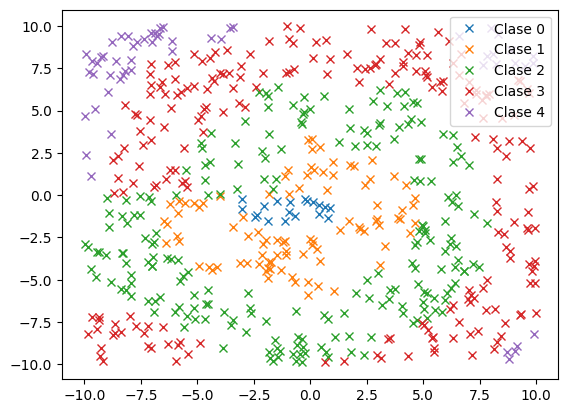

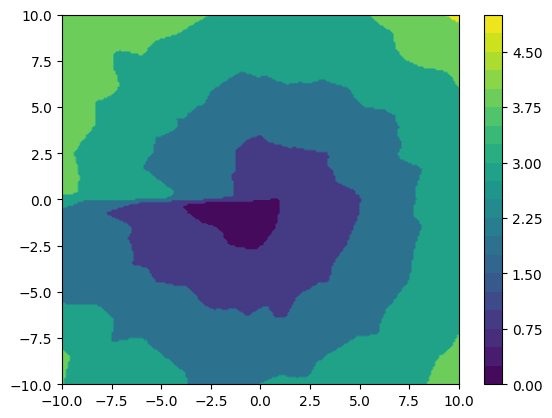

In [ ]:
with torch.no_grad():
  y_pred=model(x_test).numpy()
  pred=np.array([int(np.round(x)) for x in y_pred])
for i in range(Nc):
  l=plt.plot(X_test[pred==i,0], X_test[pred==i,1],'x', label='Clase '+str(i))
plt.legend()

x,y=np.meshgrid(np.linspace(-10,10,200),np.linspace(-10,10,200))
n,m=x.shape
vx=x.reshape(n*m,1).ravel()
vy=y.reshape(n*m,1).ravel()
X=torch.tensor(np.array([vx,vy]).T).float()
with torch.no_grad():
  y_pred=model(X).numpy()
  pred=np.array([int(np.round(x)) for x in y_pred])
x=vx.reshape(n,m)
y=vy.reshape(n,m)
z=pred.reshape(n,m)
plt.figure()
plt.contourf(x,y,z,20)
plt.colorbar()